This notebook has one purpose: to give our final, tuned model its official "final exam" on data it has never seen before.

# Imports

In [17]:
# Basics
import pandas as pd # used for data manipulation and analysis
import numpy as np # used for numerical operations
import matplotlib.pyplot as plt # used for creating visualizations
import seaborn as sns # used for creating visualizations

# TensorFlow
import tensorflow as tf # the core deep learning library

# Sklearn
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score # used for detailed evaluation reports

# Other
import joblib # used to load our saved scikit-learn preprocessor

# Setup

Before we can evaluate our model, we need to load our three essential assets into the notebook: the final tuned model we saved, the data preprocessor pipeline, and the test data.

In [2]:
# path to the final, tuned Keras model file
tuned_model_path = "../models/tuned_credit_model.keras"
# path to the PROCESSED test features we created
X_test_path = "../data/X_test_processed.csv"
# path to the test labels we created
y_test_path = "../data/y_test.csv"

Now, we'll use our defined paths to load the model, preprocessor, and test data into memory. We'll conclude by printing a summary of the loaded model to verify it's correct.

In [4]:
# load the pre-trained Keras model
final_model = tf.keras.models.load_model(tuned_model_path)
# load the processed test features
X_test = pd.read_csv(X_test_path)
# load the test labels
y_test = pd.read_csv(y_test_path).values.ravel()

# print a confirmation that the data is loaded
print("Test data loaded successfully.")
# print the shape of the test DataFrame
print(f"Test data shape: {X_test.shape}")

# display the model's architecture to confirm it loaded correctly
print("\nFinal model summary:")
final_model.summary()

Test data loaded successfully.
Test data shape: (15000, 24)

Final model summary:


Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_37 (Dense)                     │ (None, 64)                  │           1,600 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_26 (Dropout)                 │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_38 (Dense)                     │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_27 (Dropout)                 │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_39 (Dense)                     │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 11,141 (43.52 KB)

 Trainable params: 3,713 (14.50 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 7,428 (29.02 KB)

All our assets are now loaded. We have our trained model, our "recipe book" for preparing data (the preprocessor), and the new, unseen data we need to evaluate.

# Final Model Evaluation

Now we'll use our loaded model to make predictions on the test data and calculate its final performance scores.

The simplest way to get the main performance metrics is to use the model's built-in .evaluate() method. This will give us the final loss, accuracy, and AUC on our unseen test set.
* We need to re-compile the loaded model to tell it which metrics to calculate during evaluation. 

In [7]:
# RE-COMPILE the model to include the metrics for evaluation
final_model.compile(
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

In [8]:
# use the .evaluate() method to get the final loss and metrics
results = final_model.evaluate(X_test, y_test, verbose=0) # verbose=0 keeps the output clean

In [9]:
# print a header for the results
print("Final Model Performance on Test Set")
# print the test loss, formatted to 4 decimal places
print(f"Test Loss: {results[0]:.4f}")
# print the test accuracy
print(f"Test Accuracy: {results[1]:.4f}")
# print the test AUC
print(f"Test AUC: {results[2]:.4f}")

Final Model Performance on Test Set
Test Loss: 0.4271
Test Accuracy: 0.8117
Test AUC: 0.8452


Analysis of Final Test Performance:

These scores show how well our model performed on completely unseen data, which is the truest measure of its predictive power.
- AUC: A Test AUC of 0.8452 is a strong score. It's very close to the validation AUC we saw during tuning (~0.852), which is an excellent sign. This small, expected drop confirms that our model generalizes well and is not overfit to the validation data.
- Accuracy & Loss: The Test Accuracy of ~81.2% and Test Loss of 0.4271 are also highly consistent with the validation results. This demonstrates that the model's overall correctness and error rate are stable and reliable.

Overall, these results prove that we have successfully trained a robust model whose performance holds up in a real-world scenario.

# Performance Analysis

First, we need to get the model's predictions on the test set. The .predict() method will give us the probability scores, which we will then convert to our final class predictions (0 for low-risk, 1 for high-risk) using a 0.5 threshold.

In [10]:
# Get Predicted Probabilities
y_pred_probs = final_model.predict(X_test, verbose=0)

# Convert Probabilities to Class Predictions
# use a 0.5 threshold to convert probabilities to binary classes (0 or 1)
# .astype(int) converts boolean (True/False) to integer (1/0)
y_pred_classes = (y_pred_probs > 0.5).astype(int)

Next, we'll generate a classification report. This text-based report is crucial because it breaks down the precision, recall, and f1-score for each class individually, showing us how well the model performs on both low-risk and high-risk customers.

In [11]:
# compare the true labels (y_test) to the predicted labels (y_pred_classes)
report = classification_report(y_test, y_pred_classes, target_names=['Low Risk (0)', 'High Risk (1)'])

# print the detailed report
print("Classification Report")
print(report)

Classification Report
               precision    recall  f1-score   support

 Low Risk (0)       0.84      0.90      0.87     10650
High Risk (1)       0.71      0.58      0.64      4350

     accuracy                           0.81     15000
    macro avg       0.78      0.74      0.76     15000
 weighted avg       0.80      0.81      0.81     15000



This report gives us a much deeper understanding of the model's behavior, especially how it handles the imbalanced classes.

Analysis of the Classification Report:

This report confirms that while the model has a high overall accuracy, its performance differs significantly between the low-risk and high-risk classes.
- Performance on "Low Risk" (Class 0): The model is excellent at identifying low-risk customers. With a precision of 0.84 and a very high recall of 0.90, it correctly identifies 90% of all actual low-risk customers with high accuracy.
- Performance on "High Risk" (Class 1): This is where the model's main weakness lies.
    * The precision of 0.71 is decent. It means that when the model flags a customer as "High Risk," it's correct 71% of the time.
    * The recall of 0.58 is the key metric to note. This means the model successfully identifies only 58% of all the customers who were actually high-risk. The remaining 42% are missed and incorrectly classified as low-risk (false negatives).

Conclusion: The model is very reliable for identifying safe customers but is more cautious when flagging risky ones, leading it to miss a significant number of them. This highlights the classic business trade-off: the model's current state prioritizes avoiding false alarms over catching every potential defaulter.

Finally, we'll create a confusion matrix. This is the most important visualization for a classification problem, as it shows the number of correct and incorrect predictions in a clear grid format.

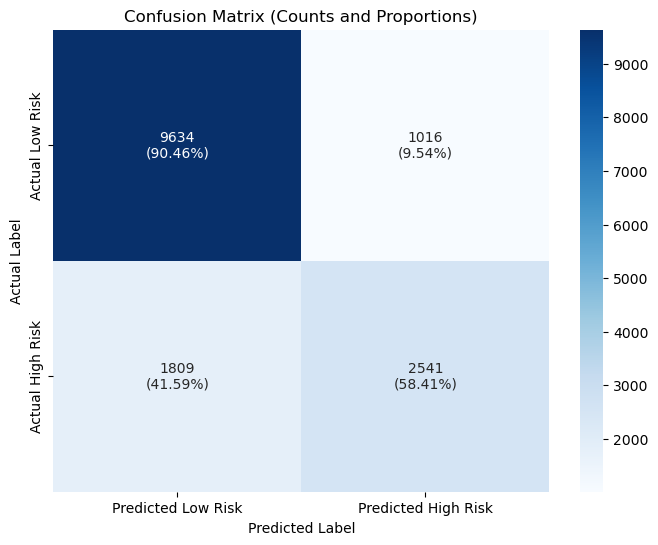

In [15]:
# create the confusion matrix with raw counts
cm = confusion_matrix(y_test, y_pred_classes)

# calculate the proportions (percentages) by normalizing along the true label rows
cm_proportions = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# create custom labels that combine the count and the proportion
labels = (
    np.asarray([
        f"{count}\n({proportion:.2%})"
        for count, proportion in zip(cm.flatten(), cm_proportions.flatten())
    ])
).reshape(cm.shape)

# --- Visualize the Matrix ---

# create a figure for the plot
plt.figure(figsize=(8, 6))
# use seaborn to create a heatmap
sns.heatmap(
    cm,                              # use the raw counts for the color scale
    annot=labels,                    # use our custom labels for the annotations
    fmt='s',                         # tell heatmap we're passing strings for annotations
    cmap='Blues',
    xticklabels=['Predicted Low Risk', 'Predicted High Risk'],
    yticklabels=['Actual Low Risk', 'Actual High Risk']
)
# add a title to the plot
plt.title('Confusion Matrix (Counts and Proportions)')
# add a label to the y-axis
plt.ylabel('Actual Label')
# add a label to the x-axis
plt.xlabel('Predicted Label')
# display the plot
plt.show()

Analysis of the Confusion Matrix:

This matrix provides a clear, visual breakdown of the model's performance, showing both the raw counts and the per-class proportions. This allows us to see not just what the model predicted, but how well it performed on each specific class.
* True Negatives: The model correctly identified 9,634 low-risk customers, which accounts for 90.46% of all actual low-risk individuals.
* True Positives: It correctly identified 2,541 high-risk customers, successfully catching 58.41% of all actual high-risk individuals. This percentage is the model's recall for the high-risk class.
* False Positives: The model incorrectly flagged 1,016 low-risk customers as high-risk, meaning 9.54% of the low-risk group were subjected to a "false alarm."
* False Negatives: Crucially, the model missed 1,809 customers who were actually high-risk, meaning 41.59% of the high-risk group were incorrectly classified as low-risk. These are the most costly errors.

The matrix clearly shows the model's biggest challenge is the low recall for the high-risk class (58.41%), which results in a high number of False Negatives where nearly 42% of risky customers are missed.

# ROC Curve Visualization

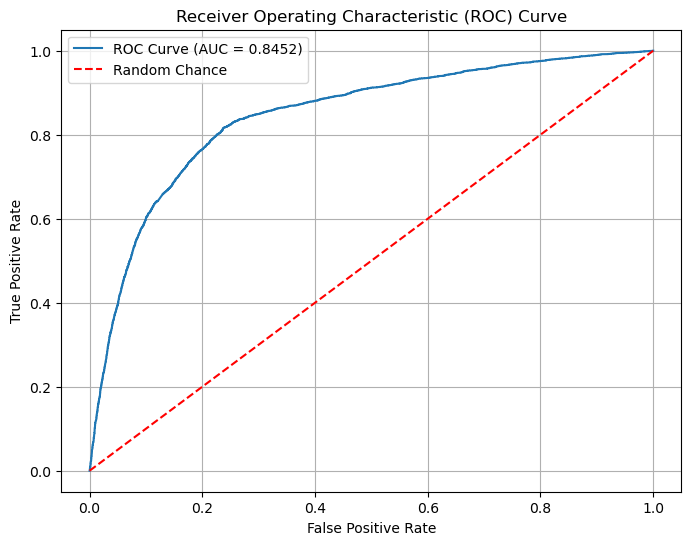

In [18]:
# calculate the false positive rate, true positive rate, and thresholds using the true labels and predicted probabilities
fpr, tpr, thresholds = roc_curve(y_test, y_pred_probs)
# calculate the final AUC score from the test set
auc_score = roc_auc_score(y_test, y_pred_probs)

# create a figure for the plot
plt.figure(figsize=(8, 6))
# plot the ROC curve, including the AUC score in the label
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {auc_score:.4f})')
# plot a dashed red line representing a random-chance model (AUC = 0.5)
plt.plot([0, 1], [0, 1], 'r--', label='Random Chance')

# add a title to the plot
plt.title('Receiver Operating Characteristic (ROC) Curve')
# add a label to the x-axis
plt.xlabel('False Positive Rate')
# add a label to the y-axis
plt.ylabel('True Positive Rate')
# display the legend
plt.legend()
# add a grid for easier reading
plt.grid(True)
# display the plot
plt.show()

Analysis of the ROC Curve

This plot provides a strong visual confirmation of our model's excellent performance on the test set.
* Confirms AUC Score: The legend shows an Area Under the Curve (AUC) of 0.8452, which perfectly matches the score we calculated earlier. This visually demonstrates the model's overall discriminative power.
* Strong Classification Ability: The blue curve bows far up and to the left, away from the red "Random Chance" line. This shape indicates that the model is very effective at distinguishing between high-risk and low-risk customers across all thresholds.
* Effective Trade-off: The steep initial slope shows that the model can achieve a high True Positive Rate (catching actual high-risk customers) while maintaining a low False Positive Rate (avoiding false alarms).